### Create DB Connection

Will be used to fetch dim tables

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import urllib 
import os
from dotenv import load_dotenv

In [2]:
# Function to fetch data from DB based on query
def fetch_data(query):

    # Load variables 
    load_dotenv('variables.env')

    # Retrieve env variables
    server = f'{os.getenv("SERVER_NAME")}'
    database = os.getenv("DB")
    user = os.getenv("USER")
    password = os.getenv("PASSWORD")

    try:
        # DB connection
        conn_string = f'mssql+pyodbc://{user}:{urllib.parse.quote_plus(password)}@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server'
    
        engine = create_engine(conn_string)
    
        df = pd.read_sql_query(query, engine)
    
        return df
        
    except Exception as err:

        print('Exception message: ', err)

### Fact Table Analysis

In [3]:
# Here I use the expanded fact table veriosn with sentiment analysis
fact_survey = pd.read_csv('fact_customer_sentiment.csv')

In [4]:
fact_survey.head(-1)

,CustomerID,SurveyYear,SurveyQuarter,SurveyDate,ResponseDate,RecommendationRate,CompanyRate,UserFrequency,QualityRate,PanelUsabilityRate,ReportCapability,SurveyID,SentimentScore,SentimentCategory,SentimentBucket
0,CRM-1516050,2022,3,2022-07-01,2022-08-26,10.0,5.0,Once a Month,5.0,5.0,I need someone from Insider team to provide me...,1,0.00,Neutral,0 to 0.49
1,CRM-1516050,2022,3,2022-07-01,2022-09-27,10.0,5.0,Once a Month,5.0,5.0,I don't use it often,2,0.00,Neutral,0 to 0.49
2,CRM-1470950,2022,1,2022-01-01,2022-03-25,4.0,3.0,Once a Day,2.0,3.0,I need someone from Insider team to provide me...,3,0.00,Neutral,0 to 0.49
3,CRM-1470950,2022,3,2022-07-01,2022-09-30,6.0,3.0,Once a Week,4.0,4.0,I tried but could not find everything I need,4,0.00,Neutral,0 to 0.49
4,CRM-1470950,2022,2,2022-04-01,2022-06-23,10.0,5.0,Once a Day,4.0,3.0,I need someone from Insider team to provide me...,5,0.00,Neutral,0 to 0.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,CRM-1500500,2022,3,2022-07-01,2022-08-16,7.0,3.0,Once a Week,3.0,3.0,I need someone from Insider team to provide me...,1984,0.00,Neutral,0 to 0.49
1984,CRM-155450,2022,1,2022-01-01,2022-03-30,7.0,3.0,Once a Day,3.0,3.0,I need someone from Insider team to provide me...,1985,0.00,Neutral,0 to 0.49
1985,CRM-155450,2022,2,2022-04-01,2022-06-30,6.0,3.0,Once a Week,4.0,4.0,I need someone from Insider team to provide me...,1986,0.00,Neutral,0 to 0.49
1986,CRM-155450,2022,3,2022-07-01,2022-09-29,7.0,4.0,Once a Week,4.0,4.0,I need someone from Insider team to provide me...,1987,0.00,Neutral,0 to 0.49


In [5]:
fact_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1989 non-null   object 
 1   SurveyYear          1989 non-null   int64  
 2   SurveyQuarter       1989 non-null   int64  
 3   SurveyDate          1989 non-null   object 
 4   ResponseDate        1989 non-null   object 
 5   RecommendationRate  1989 non-null   float64
 6   CompanyRate         1989 non-null   float64
 7   UserFrequency       1989 non-null   object 
 8   QualityRate         1989 non-null   float64
 9   PanelUsabilityRate  1989 non-null   float64
 10  ReportCapability    1989 non-null   object 
 11  SurveyID            1989 non-null   int64  
 12  SentimentScore      1989 non-null   float64
 13  SentimentCategory   1989 non-null   object 
 14  SentimentBucket     1989 non-null   object 
dtypes: float64(5), int64(3), object(7)
memory usage: 233.2+

In [6]:
# Checking unique values
fact_survey.nunique()

CustomerID             640
SurveyYear               1
SurveyQuarter            3
SurveyDate               3
ResponseDate           151
RecommendationRate      11
CompanyRate              5
UserFrequency            4
QualityRate              6
PanelUsabilityRate       6
ReportCapability         5
SurveyID              1989
SentimentScore           2
SentimentCategory        2
SentimentBucket          1
dtype: int64

In [7]:
# Checking null values
fact_survey.isnull().sum()

CustomerID            0
SurveyYear            0
SurveyQuarter         0
SurveyDate            0
ResponseDate          0
RecommendationRate    0
CompanyRate           0
UserFrequency         0
QualityRate           0
PanelUsabilityRate    0
ReportCapability      0
SurveyID              0
SentimentScore        0
SentimentCategory     0
SentimentBucket       0
dtype: int64

No null values found

In [8]:
# Column subsetof numeric columns 
fs_subset = fact_survey[['RecommendationRate','CompanyRate', 'QualityRate','PanelUsabilityRate','SentimentScore']]

fs_subset.describe().T

,count,mean,std,min,25%,50%,75%,max
RecommendationRate,1989.0,8.301156,1.634729,0.0,8.0,8.0,10.00,10.00
CompanyRate,1989.0,4.270990,0.772690,1.0,4.0,4.0,5.00,5.00
QualityRate,1989.0,4.123680,0.821484,0.0,4.0,4.0,5.00,5.00
PanelUsabilityRate,1989.0,3.906486,1.089230,0.0,3.0,4.0,5.00,5.00
SentimentScore,1989.0,0.118803,0.162148,0.0,0.0,0.0,0.34,0.34


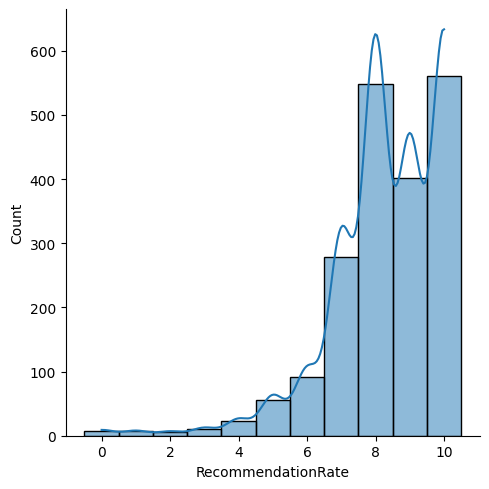

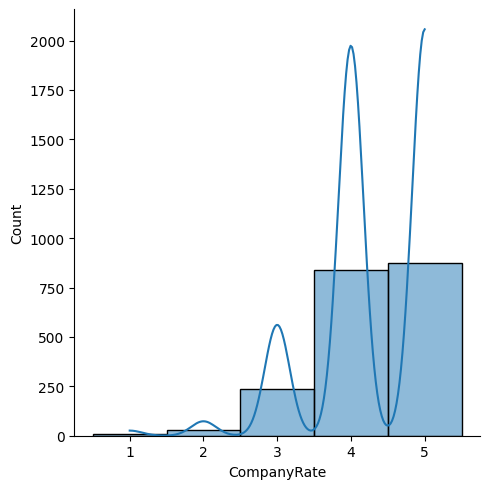

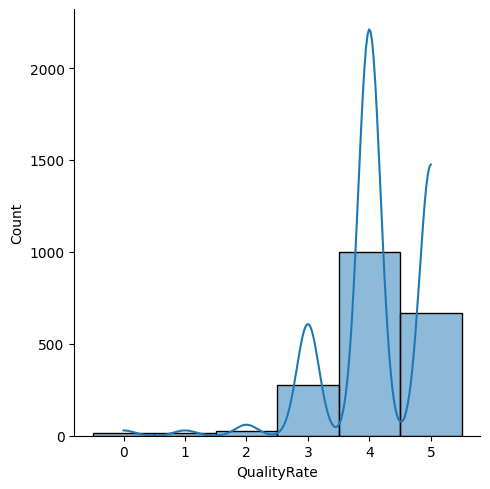

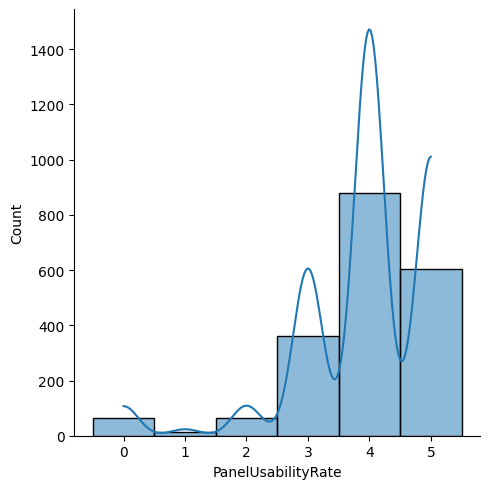

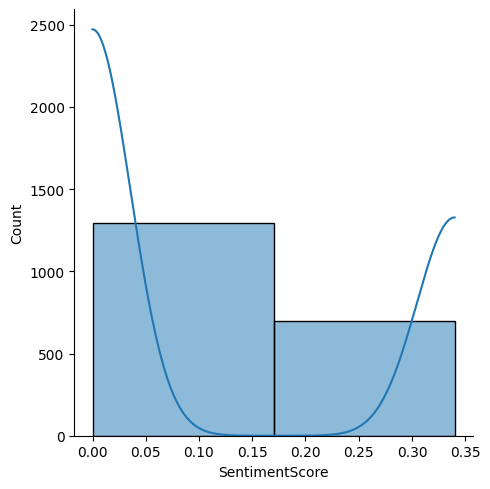

In [9]:
# Visualizing data distribution

for i, column in enumerate(fs_subset.columns):
    if(column) != 'SentimentScore':
        sns.displot(
            data = fs_subset[column], 
            kde = True, 
            discrete = True,
            binwidth = np.round(  # Tailored bin width for each distribution
                (fs_subset[f'{column}'].max() - fs_subset[f'{column}'].min()) / 
                np.sqrt(fs_subset[f'{column}'].size)
                , decimals = 0
            )
        )
    else:
        sns.displot(
            data = fs_subset[column], 
            kde = True,
            binwidth = (fs_subset[f'{column}'].max() - fs_subset[f'{column}'].min()) / 2
        )
        
plt.show()

Results: Values for all columns are skewed to the right except for the SentimentScore column which is skewed to the left

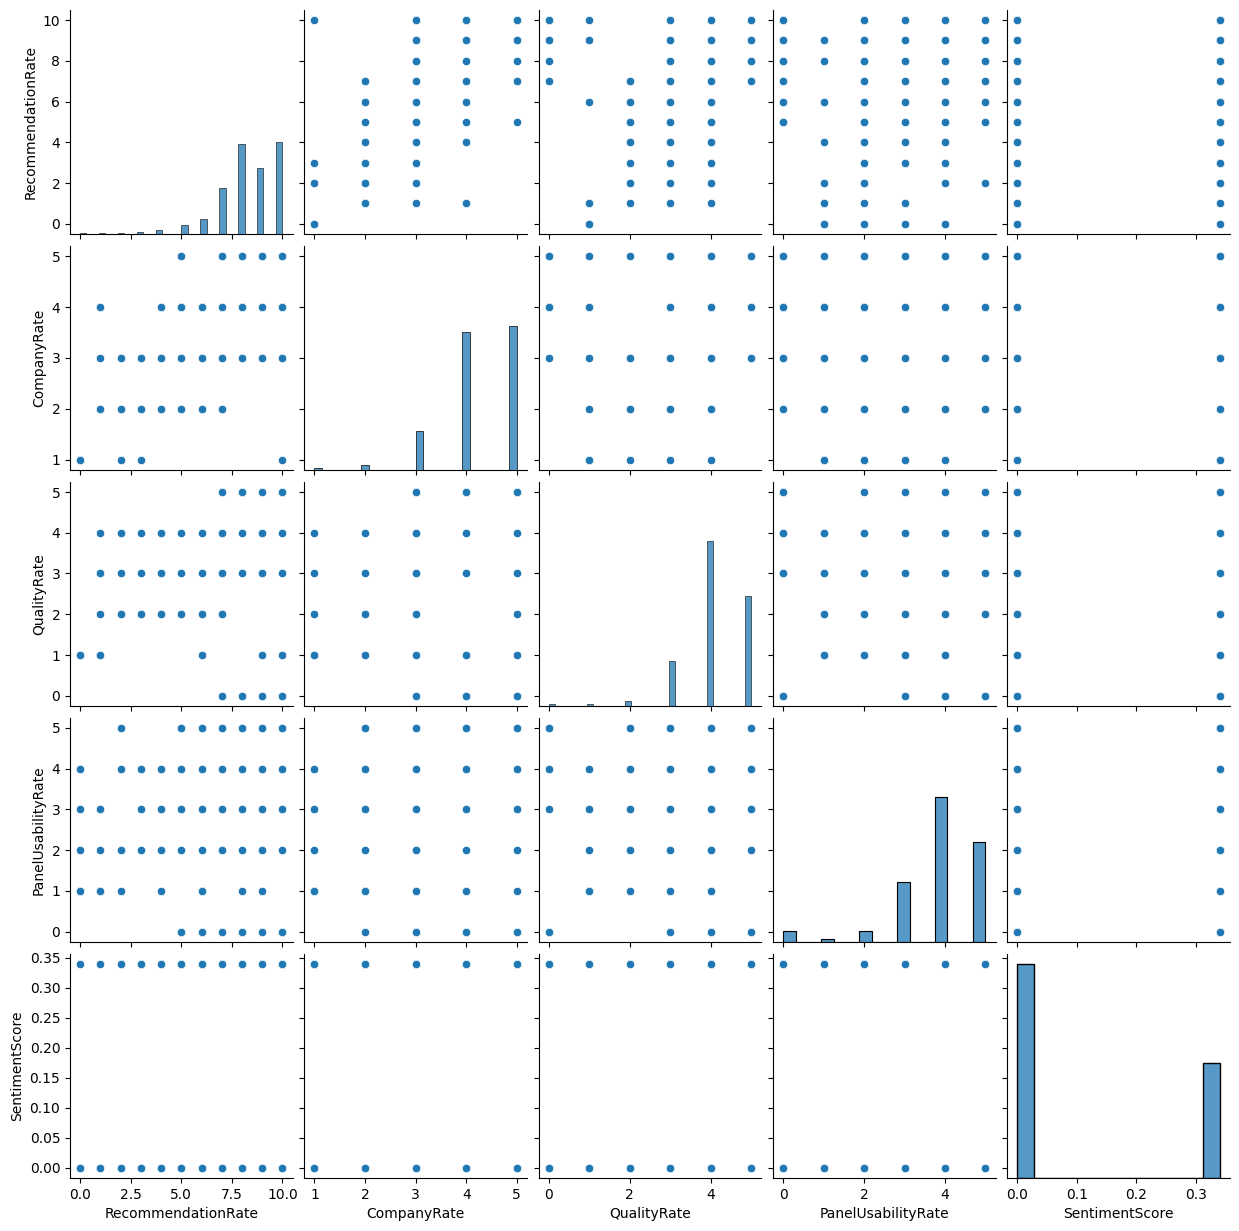

In [10]:
# Analizing trends netween variables visually 
sns.pairplot(fs_subset)
plt.show()

Graphics show some positive trend between CompanyRate, QualityRate and RecommendationRate, which might indicate a positive correlation. For the other pair of variables I cannot visually infer any trend or correlation 

Since data distribution is skewed, monotonous, discrete and N < 2000 (which is considered a small dataset) I will use Kendall´s Tau as correlation method 

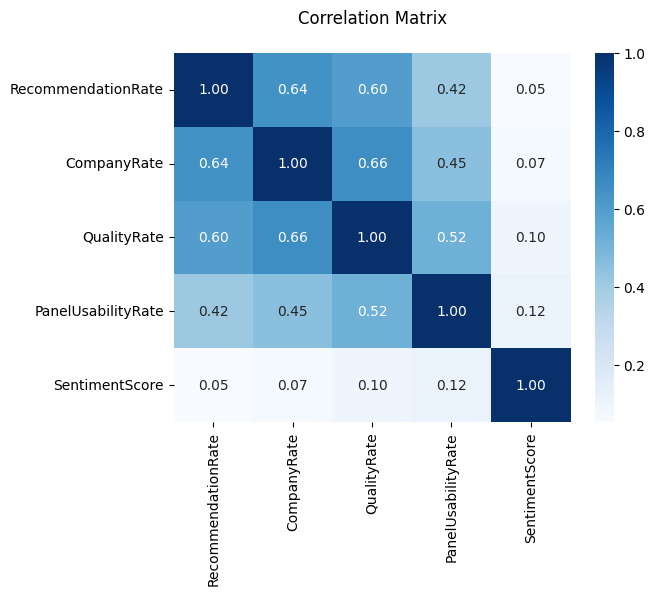

In [11]:
# Correlation matrix

corr_matrix = fs_subset.corr(method = 'kendall')

sns.heatmap(corr_matrix, annot = True, cmap = 'Blues', fmt = '.2f')

plt.title("Correlation Matrix\n")

plt.show()

Based on the matrix, we might have a moderate correlation with PanelUsability variable even when is not visible in the scatterplot so it will be added for analysis

In [12]:
from scipy.stats import kendalltau

def kendall_corr(x, y):
    
    tau, p_value = kendalltau(x, y)

    alpha = 0.05

    if p_value < alpha:
        result = "Null Hypothesis rejected"
    else:
        result = "Cannot reject Null Hypothesis and are not able to have evidence for alternative" 

    return (tau, p_value, result)

In [13]:
# Evaluate significance, excluding SentimentScore 

corr1 = kendall_corr(fs_subset['CompanyRate'], fs_subset['RecommendationRate'])
print(corr1)

corr2 = kendall_corr(fs_subset['CompanyRate'], fs_subset['PanelUsabilityRate'])
print(corr2)

corr3 = kendall_corr(fs_subset['CompanyRate'], fs_subset['QualityRate'])
print(corr3)

corr4 = kendall_corr(fs_subset['PanelUsabilityRate'], fs_subset['RecommendationRate'])
print(corr4)

corr5 = kendall_corr(fs_subset['PanelUsabilityRate'], fs_subset['QualityRate'])
print(corr5)

corr6 = kendall_corr(fs_subset['QualityRate'], fs_subset['RecommendationRate'])
print(corr6)


(np.float64(0.6427032007600799), np.float64(1.1767356338262682e-245), 'Null Hypothesis rejected')
(np.float64(0.45341102382404475), np.float64(5.6496816216964995e-115), 'Null Hypothesis rejected')
(np.float64(0.6591485515085891), np.float64(1.0339045279338576e-231), 'Null Hypothesis rejected')
(np.float64(0.4157867490658642), np.float64(5.847673798566932e-109), 'Null Hypothesis rejected')
(np.float64(0.5184937076741699), np.float64(4.3992497452629433e-151), 'Null Hypothesis rejected')
(np.float64(0.5977655625860628), np.float64(1.0376344438253868e-214), 'Null Hypothesis rejected')



Based on these results, we can say:

- There is a high positive correlation between the company rate and recommendation rate, and results are statistically significant.

- There is a high positive correlation between the quality rate for both company and recommendation rate, and results are statistically significant.
  
- There is a medium positive correlation between the panel usability rate for both company and recommendation rate, and results are statistically significant.

- There is a high positive correlation between the panel usability rate and quality rate, and results are statistically significant.

### KPIs

In [15]:
# KPIs that will be used are CSAT, CES, NPS, ART

# Defining our functions

def csat(survey_list):

    # Filtering just mixed positives surveys
    mask = fact_survey['SentimentCategory'] == 'Mixed positive'

    mixed_positives = fact_survey[mask]

    # Calculate CSAT KPI
    csat = (mixed_positives['SurveyID'].count() / survey_list['SurveyID'].count()) * 100

    return csat


def ces(survey_list):

    # Fetch all customers list from Customers view and count distinct CustomeIDs
    query = 'SELECT CustomerID FROM vCustomers'

    customers = fetch_data(query)['CustomerID'].nunique()

    # Extract distinct CustomerID count
    respondants = survey_list['CustomerID'].nunique()

    # Calculate CES KPI
    ces = ( respondants / customers ) * 100

    return ces


def nps(survey_list):

    promoters

### Customer Age Analysis

In [17]:
query = 'SELECT * FROM DimCustomerAgeData'

cust_age = fetch_data(query)

cust_age.head(-1)

,CustomerID,CustomerAgeInMonths
0,CRM-1002400,39.0
1,CRM-1005900,36.0
2,CRM-1006000,38.0
3,CRM-1010150,38.0
4,CRM-1011600,11.0
...,...,...
2645,CRM-993300,26.0
2646,CRM-997700,13.0
2647,CRM-998500,15.0
2648,CRM-998550,6.0


In [16]:
cust_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           2651 non-null   object 
 1   CustomerAgeInMonths  2651 non-null   float64
dtypes: float64(1), object(1)
memory usage: 41.6+ KB


In [18]:
cust_age['CustomerID'].nunique()

2651